In [1]:
!pip install datasets pandas sqlglot tqdm datasketch scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 3.1 MB/s eta 0:00:00


In [2]:
import sqlite3, hashlib, random, re, warnings

from datasets import load_dataset
import pandas as pd
import sqlglot
from tqdm import tqdm
import random
from sqlglot import transpile

import sqlglot.expressions as exp
from datasketch import MinHash, MinHashLSH
from sklearn.model_selection import train_test_split
from collections import defaultdict

warnings.filterwarnings('ignore')
random.seed(42)
print('Imports OK')

Imports OK


In [3]:
aug_config = {
    'tgt_rows':5000,
    'max_chains': 12,
    'chain_lengths':[1,2,3],
    'transformations':['col_subset', 'col_add_expr',
                         'filter_tautology', 'group_tautology',
                         'sort_flip', 'distinct_toggle', 'subqry_wrap'],
    'jaccard_threshold': 0.85,
    'minhash_perms' :128,
    'train_ratio':0.6,
    'test_ratio':0.2,
    'val_ratio':0.2,
    'random_seed':42
}


In [4]:
random.seed(aug_config['random_seed'])

In [6]:
print('Load Config')
print(f"  Target rows          : {aug_config['tgt_rows']:,}")
print(f"  Enabled transforms   : {len(aug_config['transformations'])}")
print(f"  Max chains / query   : {aug_config['max_chains']}")
print(f"  Chain lengths        : {aug_config['chain_lengths']}")
print(f"  Jaccard threshold    : {aug_config['jaccard_threshold']}")

Load Config
  Target rows          : 5,000
  Enabled transforms   : 7
  Max chains / query   : 12
  Chain lengths        : [1, 2, 3]
  Jaccard threshold    : 0.85


##Transformation Library

In [7]:
def safe_parse(sql, dialect='sqlite'):
    try:
        return sqlglot.parse_one(sql, read=dialect)
    except Exception:
        return None

def to_sql(tree, dialect='sqlite'):
    try:
        return tree.sql(dialect=dialect)
    except Exception:
        return None


In [8]:
def t_col_subset(tree):
    tree = tree.copy()
    exprs = tree.expressions
    non_star = [e for e in exprs if not isinstance(e, exp.Star)]
    if len(non_star) < 2:
        return None
    drop = random.choice(non_star)
    tree.set('expressions', [e for e in exprs if e is not drop])
    return tree

In [9]:
def t_col_add_expr(tree):
    tree = tree.copy()
    if tree.find(exp.Group):
        return None
    new_col = exp.Alias(
        this=exp.Literal.number(1),
        alias=exp.Identifier(this='aug_const')
    )
    tree.set('expressions', list(tree.expressions) + [new_col])
    return tree

In [10]:
def t_filter_tautology(tree):
    tree = tree.copy()
    tautology = exp.EQ(this=exp.Literal.number(1),
                       expression=exp.Literal.number(1))
    where = tree.find(exp.Where)
    if where:
        where.set('this', exp.And(this=where.this.copy(),
                                  expression=tautology))
    else:
        tree.set('where', exp.Where(this=tautology))
    return tree


In [11]:
def t_group_tautology(tree):
    tree = tree.copy()
    group = tree.find(exp.Group)
    if group is None:
        return None
    if tree.find(exp.Having):
        return None
    tautology = exp.EQ(this=exp.Literal.number(1),
                       expression=exp.Literal.number(1))
    tree.set('having', exp.Having(this=tautology))
    return tree


In [12]:
def t_sort_flip(tree):
  tree = tree.copy()
  ordered = list(tree.find_all(exp.Ordered))
  if not ordered:
      return None
  for node in ordered:
      node.set('desc', not node.args.get('desc', False))
  return tree

In [13]:
def t_distinct_toggle(tree):
  tree = tree.copy()
  if current:
    tree.set('distinct', None)
  else:
    tree.set('distinct', exp.Distinct())
  return tree

In [14]:
def t_subqry_wrap(tree):
  tree = tree.copy()
  if isinstance(tree, exp.Select):
    from_clause = tree.find(exp.From)
    if from_clause:
      subq = exp.Subquery(this=tree.copy(),alias=exp.TableAlias(this=exp.Identifier(this='aug_sub')))
      outer = exp.select(exp.Star()).from_(subq)
      return outer
  return None

In [15]:
ALL_TRANSFORMS = {
    'col_subset'         : t_col_subset,
    'col_add_expr'       : t_col_add_expr,
    'filter_tautology'       : t_filter_tautology,
    'sort_flip'            : t_sort_flip,
    'distinct_toggle'       : t_distinct_toggle,
    'subqry_wrap'         : t_subqry_wrap,
    'group_tautology'         : t_group_tautology,
}

ACTIVE_TRANSFORMS = [
    ALL_TRANSFORMS[name]
    for name in aug_config['transformations']
    if name in ALL_TRANSFORMS
]
print(f'{len(ACTIVE_TRANSFORMS)} / {len(ALL_TRANSFORMS)} transforms active.')

7 / 7 transforms active.


# Chaining , Translation, Validation

In [34]:
def apply_chain(tree, transforms, len_chain):
  rnd_trnsfrm = random.sample(transforms, len_chain)
  for trnsfrm in rnd_trnsfrm:
    try:
      tree = trnsfrm(tree)
    except Exception:
      pass
  return tree

def validate_pair_parse_only(sqlite_sql, hive_sql):
  return(
      safe_parse(sqlite_sql, dialect='sqlite') is not None and
      safe_parse(hive_sql, dialect='hive') is not None
  )

In [35]:
def augment(source_df, config, active_transforms):
    target       = config['tgt_rows']
    max_chains   = config['max_chains']
    chain_lens   = config['chain_lengths']
    seed         = config['random_seed']
    random.seed(seed)

    seen_hashes  = set()
    collected    = []

    for _, row in source_df.iterrows():
        h = hashlib.md5((row['sqlite'] + '|||' + row['hive']).encode()).hexdigest()
        if h not in seen_hashes:
            seen_hashes.add(h)
            collected.append({'sqlite': row['sqlite'],
                               'hive':   row['hive'],
                               'is_synthetic': False})

    originals_count = len(collected)
    need            = target - originals_count
    print(f'Original rows: {originals_count:,}  |  Need to generate: {need:,}')

    if need <= 0:
        print('Target already met by original data.')
        return pd.DataFrame(collected)

    rows_list      = source_df.to_dict('records')
    pass_count     = 0
    attempt_count  = 0
    round_num      = 0

    with tqdm(total=need, desc='Generating synthetic pairs') as pbar:
        while len(collected) - originals_count < need:
            round_num += 1
            random.shuffle(rows_list)

            for row in rows_list:
                if len(collected) - originals_count >= need:
                    break

                tree = safe_parse(row['sqlite'], 'sqlite')
                if tree is None:
                    continue

                for _ in range(max_chains):
                    if len(collected) - originals_count >= need:
                        break

                    chain_len  = random.choice(chain_lens)
                    new_tree   = apply_chain(tree, active_transforms, chain_len)
                    if new_tree is None:
                        continue

                    new_sqlite = to_sql(new_tree, 'sqlite')
                    if not new_sqlite:
                        continue

                    try:
                        new_hive = sqlglot.transpile(
                            new_sqlite, read='sqlite', write='hive')[0]
                    except Exception:
                        continue

                    attempt_count += 1
                    if not validate_pair_parse_only(new_sqlite, new_hive):
                        continue

                    h = hashlib.md5(
                        (new_sqlite + '|||' + new_hive).encode()).hexdigest()
                    if h in seen_hashes:
                        continue

                    seen_hashes.add(h)
                    collected.append({'sqlite': new_sqlite,
                                      'hive':   new_hive,
                                      'is_synthetic': True})
                    pass_count += 1
                    pbar.update(1)

            if round_num >= 20:
                print(f'\n⚠ Stopped after {round_num} rounds. '
                      f'Generated {pass_count:,} synthetic rows '
                      f'({len(collected):,} total). '
                      f'Increase max_chains or add more transforms to reach target.')
                break

    print(f'Done.  Attempts: {attempt_count:,}  |  '
          f'Pass rate: {100*pass_count/max(attempt_count,1):.1f}%')
    return pd.DataFrame(collected)

In [36]:
dataset= load_dataset("weizhoudb/PARROT")
dataset

DatasetDict({
    test: Dataset({
        features: ['norm', 'sqlite', 'oracle', 'id', 'tsql', 'athena', 'bigquery', 'clickhouse', 'doris', 'drill', 'druid', 'duckdb', 'databricks', 'hive', 'mysql', 'postgres', 'presto', 'redshift', 'risingwave', 'snowflake', 'spark', 'starrocks', 'teradata', 'trino'],
        num_rows: 28003
    })
})

In [37]:
df=dataset['test'].to_pandas()
len(df)

28003

In [38]:
df.columns

Index(['norm', 'sqlite', 'oracle', 'id', 'tsql', 'athena', 'bigquery',
       'clickhouse', 'doris', 'drill', 'druid', 'duckdb', 'databricks', 'hive',
       'mysql', 'postgres', 'presto', 'redshift', 'risingwave', 'snowflake',
       'spark', 'starrocks', 'teradata', 'trino'],
      dtype='object')

In [39]:
sqlite_hive_df = df[["sqlite", "hive"]].dropna()
len(sqlite_hive_df)

714

In [40]:
if "schema" in sqlite_hive_df.columns:
  unique_schema = sqlite_hive_df["schema"].nunique()
else:
  unique_schema = "Schema not available"

print(unique_schema)

Schema not available


In [41]:
def extract_tables(sql):
    tree = safe_parse(sql)
    if tree is None:
        return []
    return [t.name for t in tree.find_all(exp.Table) if t.name]

In [42]:
def classify_query_dataset(query):
  query=str(query).lower()

  low_features = ["select", "where", "limit"]
  med_features = ["join", "substring", "substr", "with"]
  hgh_features = ["window", "over", "group", "strftime", "from_unixtime", "cast"]

  if any(feature in query for feature in hgh_features):
    return "High Complexity"
  elif any(feature in query for feature in med_features):
    return "Medium Complexity"
  else:
    return "Low Complexity"

In [43]:
def classify_query_complexity(query):
    q = str(query).lower()
    if any(f in q for f in ['window','over(','group by','strftime','from_unixtime','cast(']):
        return 'High Complexity'
    elif any(f in q for f in ['join','substring','substr','with ']):
        return 'Medium Complexity'
    return 'Low Complexity'

In [44]:
sqlite_hive_df["complexity"] = sqlite_hive_df["sqlite"].apply(classify_query_dataset)

In [45]:
missing_source = sqlite_hive_df["sqlite"].isnull().sum()
missing_target = sqlite_hive_df["hive"].isnull().sum()
missing_source, missing_target

(np.int64(0), np.int64(0))

In [46]:
duplicate_count=sqlite_hive_df.duplicated(subset=["sqlite", "hive"]).sum()
duplicate_count

np.int64(46)

In [47]:
sqlite_hive_df=sqlite_hive_df.drop_duplicates(subset=["sqlite", "hive"])
sqlite_hive_df.count()

,0
sqlite,668
hive,668
complexity,668


In [48]:
invalid_sql=[]

for i, row in tqdm(sqlite_hive_df.iterrows(), total=len(sqlite_hive_df)):
  try:
    sqlglot.parse_one(row["sqlite"], read="sqlite")
    sqlglot.parse_one(row["hive"], read="hive")
  except:
    invalid_sql.append(i)

len(invalid_sql)

100%|██████████| 668/668 [00:02<00:00, 266.70it/s]


1

In [49]:
def check_encoding(text):
  try:
    str(text).encode("utf-8")
    return True
  except:
    return False

encoding_errors=sqlite_hive_df[~sqlite_hive_df["sqlite"].apply(check_encoding)]
len(encoding_errors)

0

In [50]:
def extract_tables(query):
  try:
    parsed=sqlglot.parse_one(query)
    return [table.name for table in parsed.find_all(sqlglot.exp.Table)]
  except:
    return []

sqlite_hive_df["sqlite_tables"]=sqlite_hive_df["sqlite"].apply(extract_tables)
sqlite_hive_df

,sqlite,hive,complexity,sqlite_tables
10,SELECT DISTINCT FAREalias0.FARE_ID FROM FARE A...,SELECT DISTINCT FAREalias0.FARE_ID FROM FARE A...,Low Complexity,"[FARE, FARE_BASIS, FLIGHT_FARE, FLIGHT, AIRPOR..."
31,SELECT COUNT( DISTINCT FLIGHTalias0.FLIGHT_ID ...,SELECT COUNT(DISTINCT FLIGHTalias0.FLIGHT_ID) ...,Low Complexity,"[FARE, FARE_BASIS, FLIGHT, FLIGHT_FARE]"
60,SELECT STATEalias0.STATE_NAME FROM STATE AS ST...,SELECT STATEalias0.STATE_NAME FROM STATE AS ST...,Low Complexity,"[STATE, RIVER]"
82,SELECT DISTINCT RIVERalias0.RIVER_NAME FROM RI...,SELECT DISTINCT RIVERalias0.RIVER_NAME FROM RI...,Low Complexity,"[RIVER, RIVER, RIVER, RIVER]"
134,SELECT COUNT( DISTINCT RIVERalias0.RIVER_NAME ...,SELECT COUNT(DISTINCT RIVERalias0.RIVER_NAME) ...,Low Complexity,"[RIVER, RIVER, STATE]"
...,...,...,...,...
20021,"SELECT B.team_long_name , A.buildUpPlaySpeed +...","SELECT B.team_long_name, A.buildUpPlaySpeed + ...",Medium Complexity,"[Team_Attributes, Team]"
20042,"SELECT B.player_name , MAX ( ABS ( A.potential...","SELECT B.player_name, MAX(ABS(A.potential - A....",High Complexity,"[Player_Attributes, Player]"
20064,"SELECT forename_slowest , surname_slowest , fo...","SELECT forename_slowest, surname_slowest, fore...",High Complexity,"[qualifying, races, drivers, qualifying, races..."
20085,"SELECT staff_id FROM (SELECT staff_id, strftim...","SELECT staff_id FROM (SELECT staff_id, DATE_FO...",High Complexity,"[Staff, Staff]"


In [51]:
augmented_raw = augment(sqlite_hive_df, aug_config, ACTIVE_TRANSFORMS)
print(f'\nTotal rows in augmented_raw: {len(augmented_raw):,}')

Original rows: 668  |  Need to generate: 4,332


Generating synthetic pairs: 100%|██████████| 4332/4332 [01:05<00:00, 66.42it/s]

Done.  Attempts: 7,610  |  Pass rate: 56.9%

Total rows in augmented_raw: 5,000


In [52]:
augmented_raw["complexity"] = augmented_raw["sqlite"].apply(classify_query_complexity)
augmented_raw['sqlite_tables'] = augmented_raw['sqlite'].apply(extract_tables)

In [53]:
print('Complexity distribution:')
print(augmented_raw['complexity'].value_counts())
print(f'Synthetic rows: {augmented_raw["is_synthetic"].sum():,}')
print(f'Original rows : {(~augmented_raw["is_synthetic"]).sum():,}')

Complexity distribution:
complexity
High Complexity      2707
Medium Complexity    1302
Low Complexity        991
Name: count, dtype: int64
Synthetic rows: 4,332
Original rows : 668


In [54]:
augmented_raw

,sqlite,hive,is_synthetic,complexity,sqlite_tables
0,SELECT DISTINCT FAREalias0.FARE_ID FROM FARE A...,SELECT DISTINCT FAREalias0.FARE_ID FROM FARE A...,False,Low Complexity,"[FARE, FARE_BASIS, FLIGHT_FARE, FLIGHT, AIRPOR..."
1,SELECT COUNT( DISTINCT FLIGHTalias0.FLIGHT_ID ...,SELECT COUNT(DISTINCT FLIGHTalias0.FLIGHT_ID) ...,False,Low Complexity,"[FARE, FARE_BASIS, FLIGHT, FLIGHT_FARE]"
2,SELECT STATEalias0.STATE_NAME FROM STATE AS ST...,SELECT STATEalias0.STATE_NAME FROM STATE AS ST...,False,Low Complexity,"[STATE, RIVER]"
3,SELECT DISTINCT RIVERalias0.RIVER_NAME FROM RI...,SELECT DISTINCT RIVERalias0.RIVER_NAME FROM RI...,False,Low Complexity,"[RIVER, RIVER, RIVER, RIVER]"
4,SELECT COUNT( DISTINCT RIVERalias0.RIVER_NAME ...,SELECT COUNT(DISTINCT RIVERalias0.RIVER_NAME) ...,False,Low Complexity,"[RIVER, RIVER, STATE]"
...,...,...,...,...,...
4995,"SELECT *, 1 AS aug_const FROM (SELECT CAST(SUM...","SELECT *, 1 AS aug_const FROM (SELECT CAST(SUM...",True,High Complexity,"[lapTimes, races, circuits]"
4996,SELECT CAST(SUM(T1.milliseconds) AS REAL) / CO...,SELECT CAST(SUM(T1.milliseconds) AS FLOAT) / C...,True,High Complexity,"[lapTimes, races, circuits]"
4997,"SELECT 5 + STRFTIME(""%Y"", date_left_staff) - S...",SELECT 5 + DATE_FORMAT(CAST(date_left_staff AS...,True,High Complexity,[Staff]
4998,"SELECT 30 - (STRFTIME(""%Y"", date_left_staff) -...",SELECT 30 - (DATE_FORMAT(CAST(date_left_staff ...,True,High Complexity,[Staff]


#Dataset Leakage

In [55]:
def pair_hash(row):
    return hashlib.md5(
        (row['sqlite'].strip().lower() + '|||' +
         row['hive'].strip().lower()).encode()).hexdigest()

augmented_raw['pair_hash'] = augmented_raw.apply(pair_hash, axis=1)
before = len(augmented_raw)
augmented_df = augmented_raw.drop_duplicates(
    subset='pair_hash').reset_index(drop=True)
print(f'Exact duplicates removed: {before - len(augmented_df)}  '
      f'(total: {len(augmented_df):,})')

Exact duplicates removed: 85  (total: 4,915)


In [56]:
JACCARD_THRESHOLD = aug_config['jaccard_threshold']
NUM_PERM          = aug_config['minhash_perms']

def make_minhash(text):
    m = MinHash(num_perm=NUM_PERM)
    tokens = re.split(r'\s+', text.lower())
    shingles = set()
    for tok in tokens:
        for i in range(max(1, len(tok) - 2)):
            shingles.add(tok[i:i+3])
    for s in shingles:
        m.update(s.encode('utf8'))
    return m

lsh      = MinHashLSH(threshold=JACCARD_THRESHOLD, num_perm=NUM_PERM)
minhashes = []

for idx, row in tqdm(augmented_df.iterrows(), total=len(augmented_df),
                     desc='Building MinHash index'):
    m = make_minhash(row['sqlite'])
    minhashes.append(m)
    lsh.insert(str(idx), m)

# Union-Find for grouping near-duplicates
parent = list(range(len(augmented_df)))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra

for idx in tqdm(range(len(augmented_df)), desc='Grouping near-dups'):
    for n in lsh.query(minhashes[idx]):
        nidx = int(n)
        if nidx != idx:
            union(idx, nidx)

augmented_df['sim_group'] = [find(i) for i in range(len(augmented_df))]
print(f'Unique near-duplicate groups: {augmented_df["sim_group"].nunique():,}')

Grouping near-dups: 100%|██████████| 4915/4915 [00:00<00:00, 40116.92it/s]

Unique near-duplicate groups: 1,099


In [57]:
def schema_key(tables):
    if not tables:
        return 'unknown'
    return '|'.join(sorted(set(t.lower() for t in tables)))

augmented_df['schema_key'] = augmented_df['sqlite_tables'].apply(schema_key)
augmented_df['group_id']   = (
    augmented_df['sim_group'].astype(str) + '_' + augmented_df['schema_key']
)
print(f'Unique combined (sim+schema) groups: {augmented_df["group_id"].nunique():,}')

Unique combined (sim+schema) groups: 1,147


##Exploratory Statistics

In [58]:
import re, hashlib, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import sqlglot
import sqlglot.expressions as exp
from collections import Counter, defaultdict

warnings.filterwarnings('ignore')

PALETTE   = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
BG        = '#F8F9FA'
GRID_CLR  = '#E0E0E0'

plt.rcParams.update({
    'figure.facecolor' : BG,
    'axes.facecolor'   : BG,
    'axes.grid'        : True,
    'grid.color'       : GRID_CLR,
    'grid.linewidth'   : 0.7,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})

def savefig(name):
    plt.savefig(f'{name}.png', dpi=150, bbox_inches='tight',
                facecolor=BG)
    plt.show()

print('Setup complete.')

Setup complete.


In [59]:
df = augmented_df.copy()

df['sqlite_char_len']  = df['sqlite'].str.len()
df['hive_char_len']    = df['hive'].str.len()
df['sqlite_token_len'] = df['sqlite'].str.split().str.len()
df['hive_token_len']   = df['hive'].str.split().str.len()
df['len_diff_chars']   = df['hive_char_len']   - df['sqlite_char_len']
df['len_diff_tokens']  = df['hive_token_len']  - df['sqlite_token_len']
df['len_ratio']        = (df['hive_char_len'] / df['sqlite_char_len']).round(4)

print('═'*54)
print('  DATASET OVERVIEW')
print('═'*54)
print(f'  Total pairs          : {len(df):>7,}')
print(f'  Original pairs       : {(~df["is_synthetic"]).sum():>7,}')
print(f'  Synthetic pairs      : {df["is_synthetic"].sum():>7,}')
print(f'  Unique schemas       : {df["schema_key"].nunique():>7,}')
print('─'*54)
print(f'  SQLite avg chars     : {df["sqlite_char_len"].mean():>7.1f}')
print(f'  HiveQL avg chars     : {df["hive_char_len"].mean():>7.1f}')
print(f'  SQLite avg tokens    : {df["sqlite_token_len"].mean():>7.1f}')
print(f'  HiveQL avg tokens    : {df["hive_token_len"].mean():>7.1f}')
print(f'  Avg len ratio (H/S)  : {df["len_ratio"].mean():>7.3f}')
print('═'*54)

══════════════════════════════════════════════════════
  DATASET OVERVIEW
══════════════════════════════════════════════════════
  Total pairs          :   4,915
  Original pairs       :     655
  Synthetic pairs      :   4,260
  Unique schemas       :     395
──────────────────────────────────────────────────────
  SQLite avg chars     :   278.6
  HiveQL avg chars     :   288.1
  SQLite avg tokens    :    42.9
  HiveQL avg tokens    :    43.3
  Avg len ratio (H/S)  :   1.033
══════════════════════════════════════════════════════


---
## 2. Query Length & Token Distribution

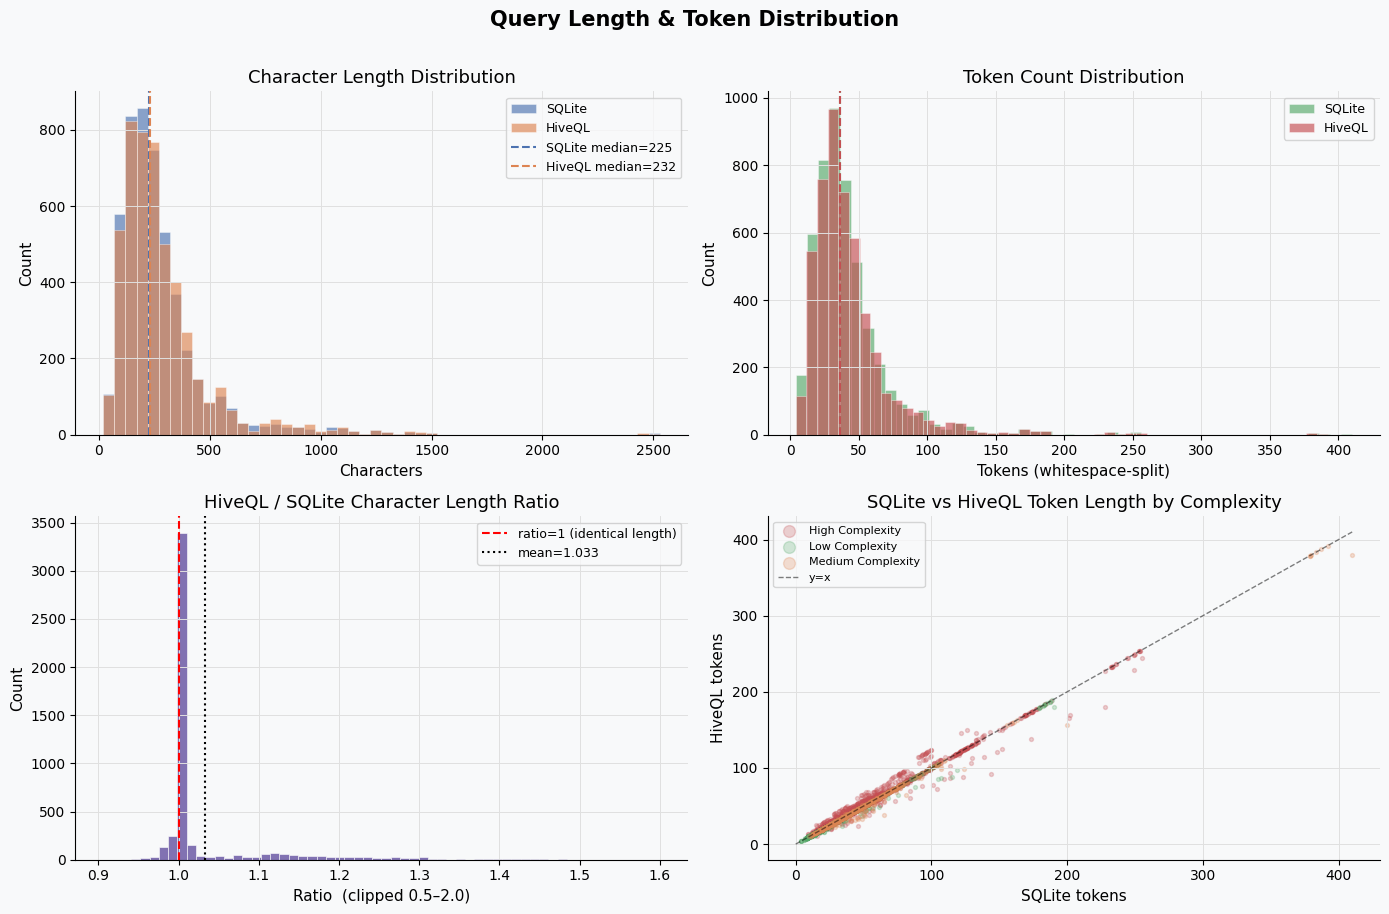

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Query Length & Token Distribution', fontsize=15, fontweight='bold', y=1.01)

ax = axes[0, 0]
ax.hist(df['sqlite_char_len'], bins=50, alpha=0.65,
        color=PALETTE[0], label='SQLite', edgecolor='white', linewidth=0.4)
ax.hist(df['hive_char_len'],   bins=50, alpha=0.65,
        color=PALETTE[1], label='HiveQL', edgecolor='white', linewidth=0.4)
ax.axvline(df['sqlite_char_len'].median(), color=PALETTE[0],
           linestyle='--', linewidth=1.5, label=f'SQLite median={df["sqlite_char_len"].median():.0f}')
ax.axvline(df['hive_char_len'].median(),   color=PALETTE[1],
           linestyle='--', linewidth=1.5, label=f'HiveQL median={df["hive_char_len"].median():.0f}')
ax.set_title('Character Length Distribution')
ax.set_xlabel('Characters')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

ax = axes[0, 1]
ax.hist(df['sqlite_token_len'], bins=50, alpha=0.65,
        color=PALETTE[2], label='SQLite', edgecolor='white', linewidth=0.4)
ax.hist(df['hive_token_len'],   bins=50, alpha=0.65,
        color=PALETTE[3], label='HiveQL', edgecolor='white', linewidth=0.4)
ax.axvline(df['sqlite_token_len'].median(), color=PALETTE[2],
           linestyle='--', linewidth=1.5)
ax.axvline(df['hive_token_len'].median(),   color=PALETTE[3],
           linestyle='--', linewidth=1.5)
ax.set_title('Token Count Distribution')
ax.set_xlabel('Tokens (whitespace-split)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

ax = axes[1, 0]
clipped = df['len_ratio'].clip(0.5, 2.0)
ax.hist(clipped, bins=60, color=PALETTE[4], edgecolor='white', linewidth=0.4)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='ratio=1 (identical length)')
ax.axvline(df['len_ratio'].mean(), color='black',
           linestyle=':', linewidth=1.5, label=f'mean={df["len_ratio"].mean():.3f}')
ax.set_title('HiveQL / SQLite Character Length Ratio')
ax.set_xlabel('Ratio  (clipped 0.5–2.0)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

ax = axes[1, 1]
colors_map = {'High Complexity': PALETTE[3],
              'Medium Complexity': PALETTE[1],
              'Low Complexity': PALETTE[2]}
for cmplx, grp in df.groupby('complexity'):
    ax.scatter(grp['sqlite_token_len'], grp['hive_token_len'],
               alpha=0.25, s=8, color=colors_map.get(cmplx, 'grey'),
               label=cmplx)
max_tok = max(df['sqlite_token_len'].max(), df['hive_token_len'].max())
ax.plot([0, max_tok], [0, max_tok], 'k--', linewidth=1, alpha=0.5, label='y=x')
ax.set_title('SQLite vs HiveQL Token Length by Complexity')
ax.set_xlabel('SQLite tokens')
ax.set_ylabel('HiveQL tokens')
ax.legend(fontsize=8, markerscale=3)

plt.tight_layout()
savefig('plot_01_length_distribution')

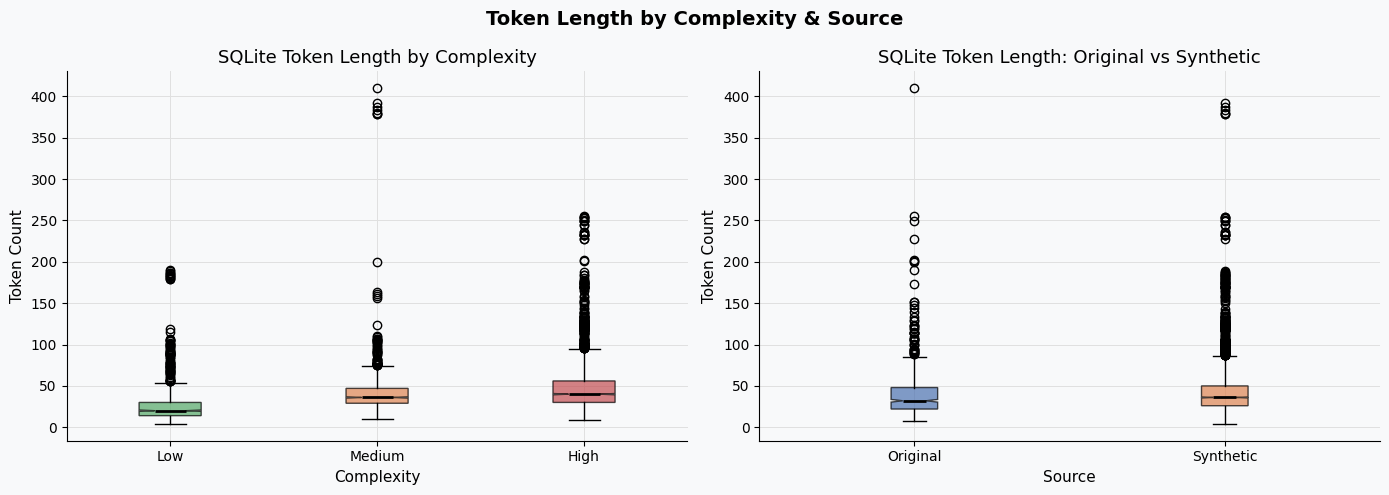

In [61]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Token Length by Complexity & Source', fontsize=14, fontweight='bold')

ax = axes[0]
order = ['Low Complexity', 'Medium Complexity', 'High Complexity']
data_by_cmplx = [df[df['complexity']==c]['sqlite_token_len'].values for c in order]
bp = ax.boxplot(data_by_cmplx, patch_artist=True, notch=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], [PALETTE[2], PALETTE[1], PALETTE[3]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_title('SQLite Token Length by Complexity')
ax.set_ylabel('Token Count')
ax.set_xlabel('Complexity')

ax = axes[1]
data_by_src = [
    df[~df['is_synthetic']]['sqlite_token_len'].values,
    df[ df['is_synthetic']]['sqlite_token_len'].values,
]
bp2 = ax.boxplot(data_by_src, patch_artist=True, notch=True,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], [PALETTE[0], PALETTE[1]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticklabels(['Original', 'Synthetic'])
ax.set_title('SQLite Token Length: Original vs Synthetic')
ax.set_ylabel('Token Count')
ax.set_xlabel('Source')

plt.tight_layout()
savefig('plot_02_boxplots')

---
## 3. Complexity Distribution

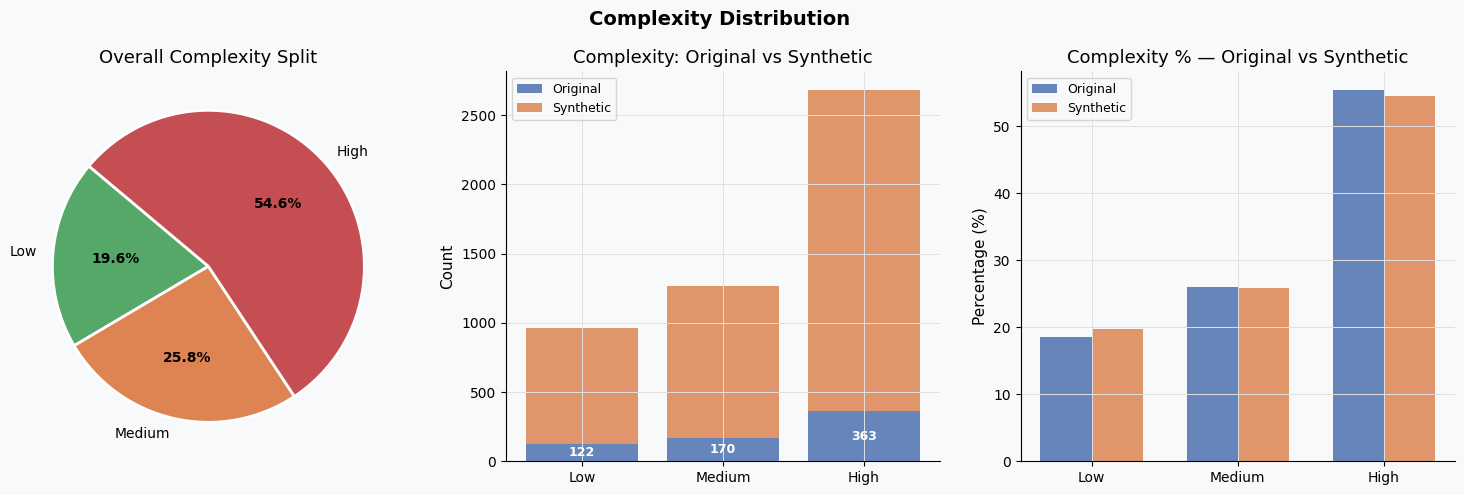

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Complexity Distribution', fontsize=14, fontweight='bold')

cmplx_order  = ['Low Complexity','Medium Complexity','High Complexity']
cmplx_labels = ['Low','Medium','High']
cmplx_colors = [PALETTE[2], PALETTE[1], PALETTE[3]]

ax = axes[0]
counts = df['complexity'].value_counts().reindex(cmplx_order)
wedges, texts, autotexts = ax.pie(
    counts, labels=cmplx_labels, colors=cmplx_colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Overall Complexity Split')

ax = axes[1]
orig_counts  = df[~df['is_synthetic']]['complexity'].value_counts().reindex(cmplx_order, fill_value=0)
synth_counts = df[ df['is_synthetic']]['complexity'].value_counts().reindex(cmplx_order, fill_value=0)
x = np.arange(3)
b1 = ax.bar(x, orig_counts.values,  label='Original',  color=PALETTE[0], alpha=0.85)
b2 = ax.bar(x, synth_counts.values, bottom=orig_counts.values,
            label='Synthetic', color=PALETTE[1], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cmplx_labels)
ax.set_title('Complexity: Original vs Synthetic')
ax.set_ylabel('Count')
ax.legend(fontsize=9)
for bar in b1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x()+bar.get_width()/2, h/2, str(int(h)),
                ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax = axes[2]
orig_pct  = (orig_counts  / orig_counts.sum()  * 100).round(1)
synth_pct = (synth_counts / synth_counts.sum() * 100).round(1)
x_pos = np.arange(3)
w = 0.35
ax.bar(x_pos - w/2, orig_pct.values,  w, label='Original',  color=PALETTE[0], alpha=0.85)
ax.bar(x_pos + w/2, synth_pct.values, w, label='Synthetic', color=PALETTE[1], alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(cmplx_labels)
ax.set_title('Complexity % — Original vs Synthetic')
ax.set_ylabel('Percentage (%)')
ax.legend(fontsize=9)

plt.tight_layout()
savefig('plot_03_complexity')

---
## 4. SQL Feature Coverage

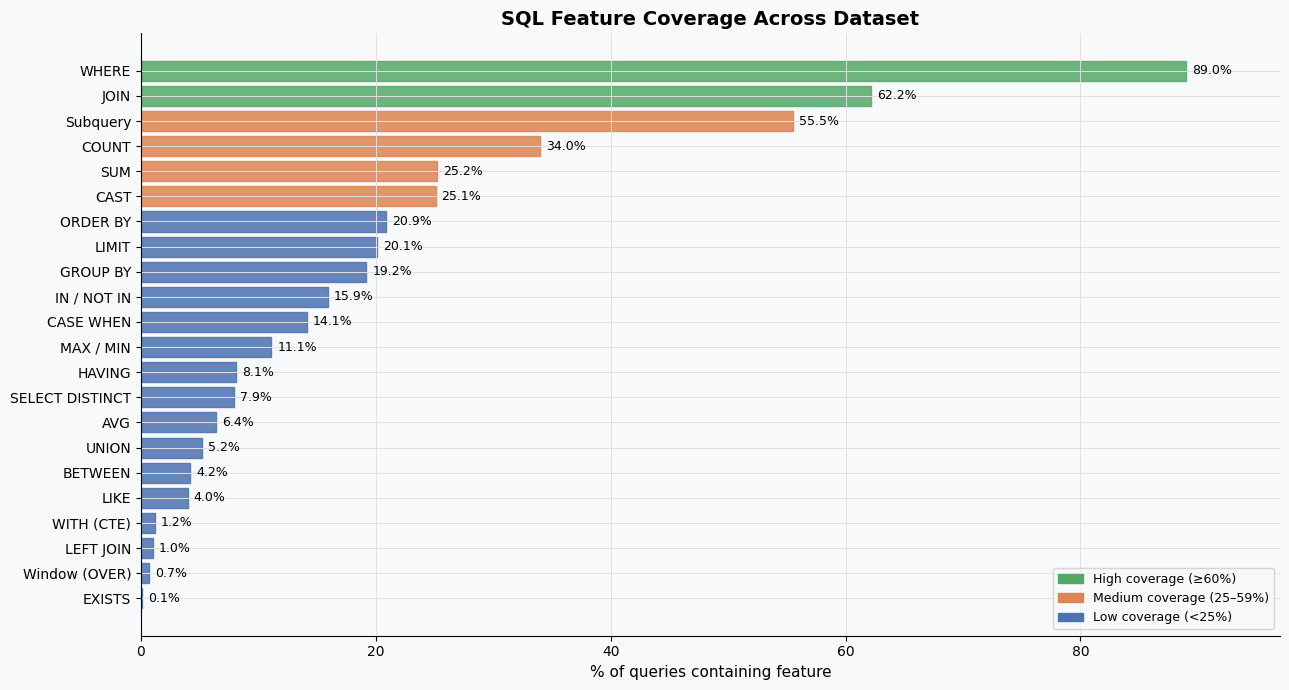

In [63]:
SQL_FEATURES = {
    'SELECT DISTINCT' : r'\bselect\s+distinct\b',
    'WHERE'           : r'\bwhere\b',
    'JOIN'            : r'\bjoin\b',
    'LEFT JOIN'       : r'\bleft\s+join\b',
    'GROUP BY'        : r'\bgroup\s+by\b',
    'HAVING'          : r'\bhaving\b',
    'ORDER BY'        : r'\border\s+by\b',
    'LIMIT'           : r'\blimit\b',
    'Subquery'        : r'\bselect\b.*?\bfrom\b.*?\bselect\b',
    'WITH (CTE)'      : r'\bwith\b',
    'CAST'            : r'\bcast\s*\(',
    'CASE WHEN'       : r'\bcase\s+when\b',
    'COUNT'           : r'\bcount\s*\(',
    'SUM'             : r'\bsum\s*\(',
    'AVG'             : r'\bavg\s*\(',
    'MAX / MIN'       : r'\b(max|min)\s*\(',
    'LIKE'            : r'\blike\b',
    'IN / NOT IN'     : r'\b(not\s+)?in\s*\(',
    'BETWEEN'         : r'\bbetween\b',
    'EXISTS'          : r'\bexists\s*\(',
    'UNION'           : r'\bunion\b',
    'Window (OVER)'   : r'\bover\s*\(',
}

for feat, pattern in SQL_FEATURES.items():
    df[f'feat_{feat}'] = df['sqlite'].str.lower().str.contains(
        pattern, regex=True, na=False)

feat_cols   = [c for c in df.columns if c.startswith('feat_')]
feat_counts = df[feat_cols].sum().sort_values(ascending=False)
feat_labels = [c.replace('feat_','') for c in feat_counts.index]
feat_pcts   = (feat_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(feat_labels[::-1], feat_pcts.values[::-1],
               color=PALETTE[0], alpha=0.85, edgecolor='white')

for bar, pct in zip(bars, feat_pcts.values[::-1]):
    if pct >= 60:
        bar.set_color(PALETTE[2])
    elif pct >= 25:
        bar.set_color(PALETTE[1])
    else:
        bar.set_color(PALETTE[0])
    ax.text(pct + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)

patches = [
    mpatches.Patch(color=PALETTE[2], label='High coverage (≥60%)'),
    mpatches.Patch(color=PALETTE[1], label='Medium coverage (25–59%)'),
    mpatches.Patch(color=PALETTE[0], label='Low coverage (<25%)'),
]
ax.legend(handles=patches, fontsize=9, loc='lower right')
ax.set_xlabel('% of queries containing feature')
ax.set_title('SQL Feature Coverage Across Dataset', fontsize=14, fontweight='bold')
ax.set_xlim(0, feat_pcts.max() + 8)
plt.tight_layout()
savefig('plot_04_sql_features')

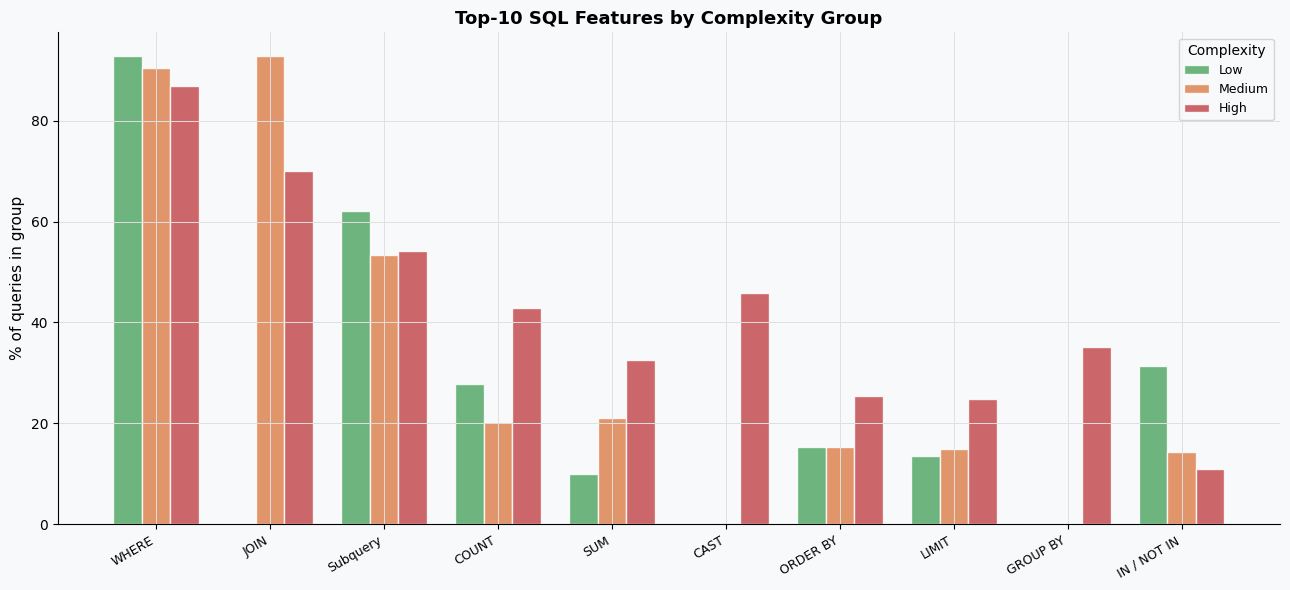

In [64]:
top_feats = [c for c in feat_counts.head(10).index]
top_labels = [c.replace('feat_','') for c in top_feats]

fig, ax = plt.subplots(figsize=(13, 6))
x  = np.arange(len(top_feats))
w  = 0.25

for i, (cmplx, color) in enumerate(zip(cmplx_order, cmplx_colors)):
    sub = df[df['complexity'] == cmplx]
    pcts = [(sub[f].sum() / len(sub) * 100) for f in top_feats]
    ax.bar(x + i*w, pcts, w, label=cmplx.replace(' Complexity',''),
           color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + w)
ax.set_xticklabels(top_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('% of queries in group')
ax.set_title('Top-10 SQL Features by Complexity Group', fontsize=13, fontweight='bold')
ax.legend(title='Complexity', fontsize=9)
plt.tight_layout()
savefig('plot_05_features_by_complexity')

---
## 5. Schema & Table Analysis

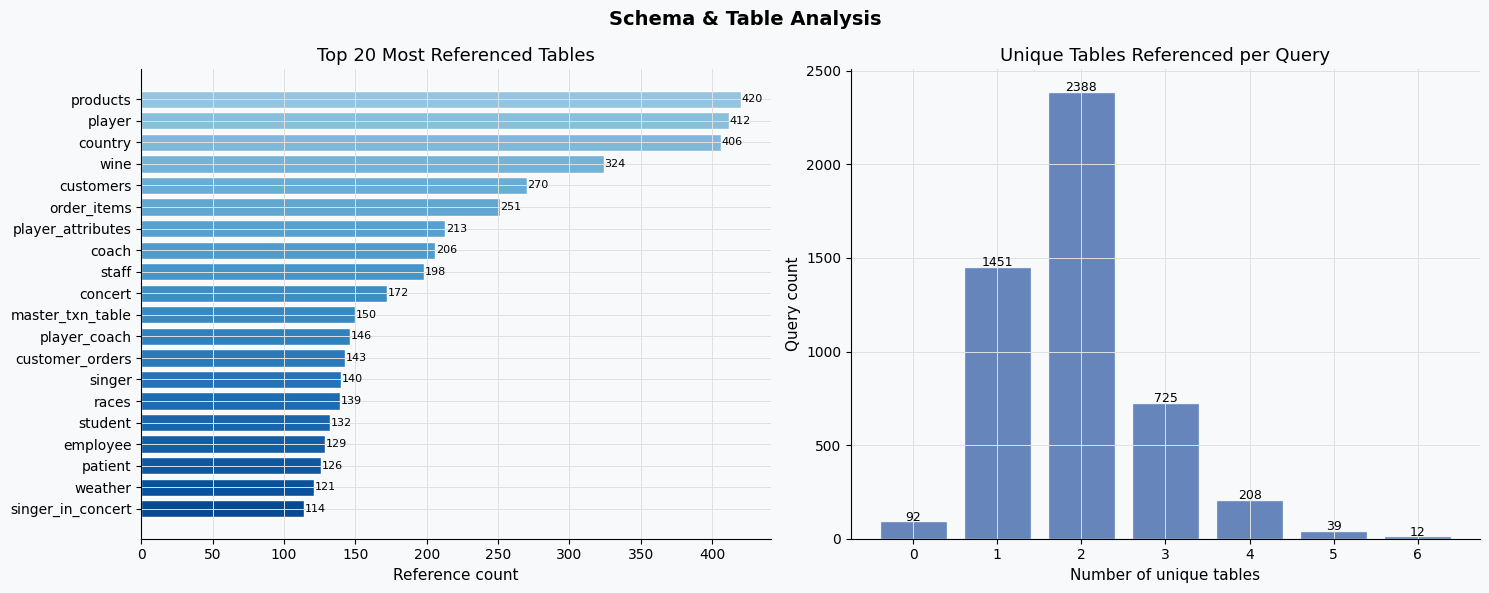

In [65]:
all_tables = [t.lower() for tables in df['sqlite_tables'] for t in tables]
table_counts = Counter(all_tables).most_common(20)
t_names = [t for t, _ in table_counts]
t_vals  = [c for _, c in table_counts]

df['n_tables'] = df['sqlite_tables'].apply(lambda x: len(set(t.lower() for t in x)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Schema & Table Analysis', fontsize=14, fontweight='bold')

ax = axes[0]
cmap_vals = plt.cm.Blues(np.linspace(0.4, 0.9, len(t_vals)))
ax.barh(t_names[::-1], t_vals[::-1], color=cmap_vals[::-1], edgecolor='white')
ax.set_title('Top 20 Most Referenced Tables')
ax.set_xlabel('Reference count')
for i, v in enumerate(t_vals[::-1]):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=8)

ax = axes[1]
n_table_counts = df['n_tables'].value_counts().sort_index()
ax.bar(n_table_counts.index, n_table_counts.values,
       color=PALETTE[0], alpha=0.85, edgecolor='white')
ax.set_title('Unique Tables Referenced per Query')
ax.set_xlabel('Number of unique tables')
ax.set_ylabel('Query count')
for xi, yi in zip(n_table_counts.index, n_table_counts.values):
    ax.text(xi, yi + 5, str(yi), ha='center', fontsize=9)

plt.tight_layout()
savefig('plot_06_schema_analysis')

---
## 6. Translation Divergence Analysis

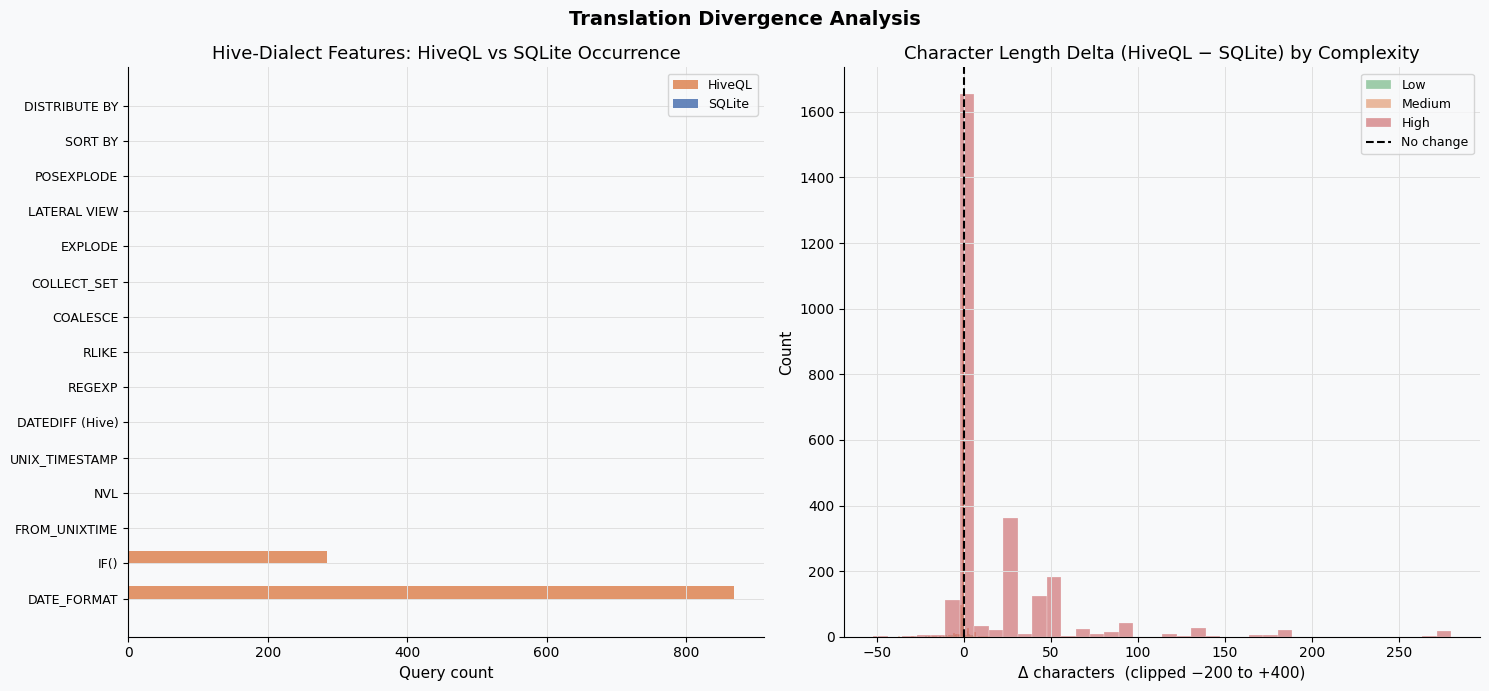

In [66]:
HIVE_PATTERNS = {
    'DATE_FORMAT'     : r'\bdate_format\b',
    'FROM_UNIXTIME'   : r'\bfrom_unixtime\b',
    'IF()'            : r'\bif\s*\(',
    'NVL'             : r'\bnvl\s*\(',
    'UNIX_TIMESTAMP'  : r'\bunix_timestamp\b',
    'DATEDIFF (Hive)' : r'\bdatediff\b',
    'REGEXP'          : r'\bregexp\b',
    'RLIKE'           : r'\brlike\b',
    'COALESCE'        : r'\bcoalesce\b',
    'COLLECT_SET'     : r'\bcollect_set\b',
    'EXPLODE'         : r'\bexplode\b',
    'LATERAL VIEW'    : r'\blateral\s+view\b',
    'POSEXPLODE'      : r'\bposexplode\b',
    'SORT BY'         : r'\bsort\s+by\b',
    'DISTRIBUTE BY'   : r'\bdistribute\s+by\b',
}

hive_feat_data = {}
for feat, pat in HIVE_PATTERNS.items():
    in_hive   = df['hive'].str.lower().str.contains(pat, regex=True, na=False).sum()
    in_sqlite = df['sqlite'].str.lower().str.contains(pat, regex=True, na=False).sum()
    hive_feat_data[feat] = {'HiveQL': in_hive, 'SQLite': in_sqlite}

hive_feat_df = pd.DataFrame(hive_feat_data).T.sort_values('HiveQL', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Translation Divergence Analysis', fontsize=14, fontweight='bold')

ax = axes[0]
y  = np.arange(len(hive_feat_df))
w  = 0.35
ax.barh(y + w/2, hive_feat_df['HiveQL'], w,  label='HiveQL',  color=PALETTE[1], alpha=0.85)
ax.barh(y - w/2, hive_feat_df['SQLite'], w,  label='SQLite',  color=PALETTE[0], alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(hive_feat_df.index, fontsize=9)
ax.set_title('Hive-Dialect Features: HiveQL vs SQLite Occurrence')
ax.set_xlabel('Query count')
ax.legend(fontsize=9)

ax = axes[1]
for cmplx, color in zip(cmplx_order, cmplx_colors):
    sub = df[df['complexity']==cmplx]['len_diff_chars'].clip(-200, 400)
    ax.hist(sub, bins=40, alpha=0.55, color=color,
            label=cmplx.replace(' Complexity',''), edgecolor='white', linewidth=0.3)
ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='No change')
ax.set_title('Character Length Delta (HiveQL − SQLite) by Complexity')
ax.set_xlabel('Δ characters  (clipped −200 to +400)')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

plt.tight_layout()
savefig('plot_07_translation_divergence')

---
## 7. Data Quality Checks

In [67]:
quality_results = {}

quality_results['Missing SQLite']  = df['sqlite'].isna().sum()
quality_results['Missing HiveQL']  = df['hive'].isna().sum()

quality_results['Empty SQLite']    = (df['sqlite'].str.strip() == '').sum()
quality_results['Empty HiveQL']    = (df['hive'].str.strip()   == '').sum()

quality_results['Exact dup pairs'] = df.duplicated(subset=['sqlite','hive']).sum()

quality_results['Non-SELECT SQLite'] = (~df['sqlite'].str.strip().str.upper().str.startswith('SELECT')).sum()
quality_results['Non-SELECT HiveQL'] = (~df['hive'].str.strip().str.upper().str.startswith('SELECT')).sum()

def count_parse_failures(series, dialect):
    fails = 0
    for sql in series:
        try:
            sqlglot.parse_one(str(sql), read=dialect)
        except Exception:
            fails += 1
    return fails

print('Running parse checks (this may take ~30s)...')
quality_results['SQLite parse fails'] = count_parse_failures(df['sqlite'], 'sqlite')
quality_results['HiveQL parse fails'] = count_parse_failures(df['hive'],   'hive')

def has_encoding_issue(text):
    try:
        str(text).encode('utf-8').decode('utf-8')
        return False
    except Exception:
        return True

quality_results['Encoding issues SQLite'] = df['sqlite'].apply(has_encoding_issue).sum()
quality_results['Encoding issues HiveQL'] = df['hive'].apply(has_encoding_issue).sum()

quality_results['SQLite < 10 chars']  = (df['sqlite_char_len'] < 10).sum()
quality_results['HiveQL < 10 chars']  = (df['hive_char_len']   < 10).sum()

quality_results['SQLite > 2000 chars'] = (df['sqlite_char_len'] > 2000).sum()
quality_results['HiveQL > 2000 chars'] = (df['hive_char_len']   > 2000).sum()

quality_results['SQLite == HiveQL (identical)'] = (
    df['sqlite'].str.strip().str.lower() == df['hive'].str.strip().str.lower()).sum()

qdf = pd.DataFrame.from_dict(quality_results, orient='index', columns=['Count'])
qdf['% of total'] = (qdf['Count'] / len(df) * 100).round(3)
qdf['Status'] = qdf['Count'].apply(
    lambda x: '✅ OK' if x == 0 else ('⚠️ Warn' if x < len(df)*0.01 else '❌ Issue')
)
print('\n── DATA QUALITY RESULTS ──')
print(qdf.to_string())

Running parse checks (this may take ~30s)...

── DATA QUALITY RESULTS ──
                              Count  % of total   Status
Missing SQLite                    0       0.000     ✅ OK
Missing HiveQL                    0       0.000     ✅ OK
Empty SQLite                      0       0.000     ✅ OK
Empty HiveQL                      0       0.000     ✅ OK
Exact dup pairs                   0       0.000     ✅ OK
Non-SELECT SQLite                53       1.078  ❌ Issue
Non-SELECT HiveQL                70       1.424  ❌ Issue
SQLite parse fails                0       0.000     ✅ OK
HiveQL parse fails                1       0.020  ⚠️ Warn
Encoding issues SQLite            0       0.000     ✅ OK
Encoding issues HiveQL            0       0.000     ✅ OK
SQLite < 10 chars                 0       0.000     ✅ OK
HiveQL < 10 chars                 0       0.000     ✅ OK
SQLite > 2000 chars               7       0.142  ⚠️ Warn
HiveQL > 2000 chars               7       0.142  ⚠️ Warn
SQLite == HiveQ

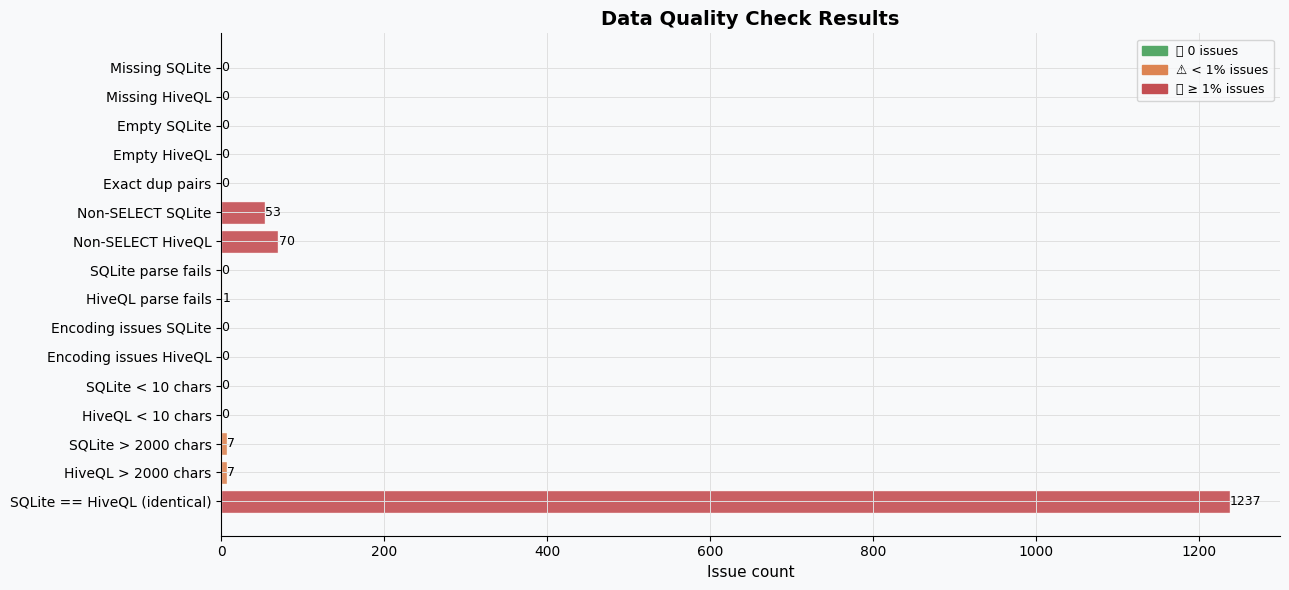

In [68]:

fig, ax = plt.subplots(figsize=(13, 6))

bar_colors = []
for v in qdf['Count']:
    if v == 0:
        bar_colors.append(PALETTE[2])
    elif v < len(df) * 0.01:
        bar_colors.append(PALETTE[1])
    else:
        bar_colors.append(PALETTE[3])

bars = ax.barh(qdf.index[::-1], qdf['Count'].values[::-1],
               color=bar_colors[::-1], edgecolor='white', alpha=0.9)

for bar, val in zip(bars, qdf['Count'].values[::-1]):
    ax.text(max(val + 0.3, 0.3), bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=9)

patches = [
    mpatches.Patch(color=PALETTE[2], label='✅ 0 issues'),
    mpatches.Patch(color=PALETTE[1], label='⚠️ < 1% issues'),
    mpatches.Patch(color=PALETTE[3], label='❌ ≥ 1% issues'),
]
ax.legend(handles=patches, fontsize=9)
ax.set_title('Data Quality Check Results', fontsize=14, fontweight='bold')
ax.set_xlabel('Issue count')
plt.tight_layout()
savefig('plot_08_quality_checks')

---
## 8. Advanced: AST Depth Distribution

In [69]:
def ast_depth(sql, dialect='sqlite'):
    """Return the maximum depth of the sqlglot AST tree."""
    try:
        tree = sqlglot.parse_one(sql, read=dialect)
        if tree is None:
            return np.nan

        def _depth(node, d=0):
            children = list(node.args.values())
            children = [c for c in children if isinstance(c, exp.Expression)]
            if not children:
                return d
            return max(_depth(c, d+1) for c in children)

        return _depth(tree)
    except Exception:
        return np.nan

print('Computing AST depths (takes ~1–2 min)...')
df['ast_depth_sqlite'] = df['sqlite'].apply(lambda s: ast_depth(s, 'sqlite'))
df['ast_depth_hive']   = df['hive'].apply(  lambda s: ast_depth(s, 'hive'))

print(f'SQLite AST depth  — mean: {df["ast_depth_sqlite"].mean():.2f},  '
      f'max: {df["ast_depth_sqlite"].max()}')
print(f'HiveQL AST depth  — mean: {df["ast_depth_hive"].mean():.2f},  '
      f'max: {df["ast_depth_hive"].max()}')

Computing AST depths (takes ~1–2 min)...
SQLite AST depth  — mean: 7.23,  max: 27
HiveQL AST depth  — mean: 7.35,  max: 27.0


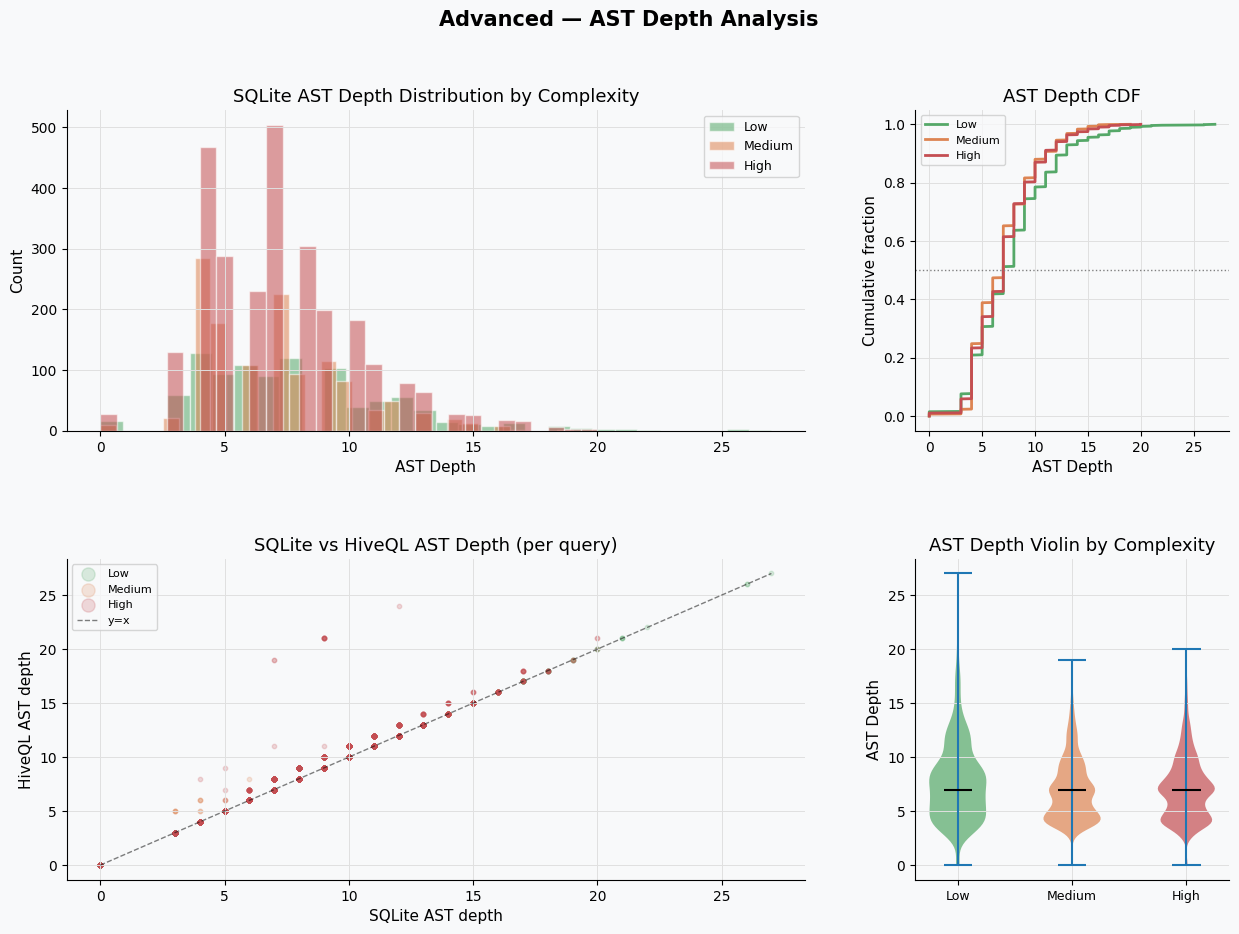

In [70]:
fig = plt.figure(figsize=(15, 10))
fig.suptitle('Advanced — AST Depth Analysis', fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax = fig.add_subplot(gs[0, :2])
for cmplx, color in zip(cmplx_order, cmplx_colors):
    sub = df[df['complexity']==cmplx]['ast_depth_sqlite'].dropna()
    ax.hist(sub, bins=30, alpha=0.55, color=color,
            label=cmplx.replace(' Complexity',''), edgecolor='white')
ax.set_title('SQLite AST Depth Distribution by Complexity')
ax.set_xlabel('AST Depth')
ax.set_ylabel('Count')
ax.legend(fontsize=9)

ax = fig.add_subplot(gs[0, 2])
for cmplx, color in zip(cmplx_order, cmplx_colors):
    sub = df[df['complexity']==cmplx]['ast_depth_sqlite'].dropna().sort_values()
    ax.plot(sub.values, np.linspace(0,1,len(sub)),
            color=color, linewidth=2,
            label=cmplx.replace(' Complexity',''))
ax.set_title('AST Depth CDF')
ax.set_xlabel('AST Depth')
ax.set_ylabel('Cumulative fraction')
ax.legend(fontsize=8)
ax.axhline(0.5, color='grey', linestyle=':', linewidth=1)

ax = fig.add_subplot(gs[1, :2])
valid = df[['ast_depth_sqlite','ast_depth_hive','complexity']].dropna()
for cmplx, color in zip(cmplx_order, cmplx_colors):
    sub = valid[valid['complexity']==cmplx]
    ax.scatter(sub['ast_depth_sqlite'], sub['ast_depth_hive'],
               alpha=0.2, s=10, color=color,
               label=cmplx.replace(' Complexity',''))
max_d = max(valid['ast_depth_sqlite'].max(), valid['ast_depth_hive'].max())
ax.plot([0,max_d],[0,max_d],'k--',linewidth=1,alpha=0.5, label='y=x')
ax.set_title('SQLite vs HiveQL AST Depth (per query)')
ax.set_xlabel('SQLite AST depth')
ax.set_ylabel('HiveQL AST depth')
ax.legend(fontsize=8, markerscale=3)

ax = fig.add_subplot(gs[1, 2])
violin_data = [df[df['complexity']==c]['ast_depth_sqlite'].dropna().values
               for c in cmplx_order]
parts = ax.violinplot(violin_data, positions=[1,2,3],
                      showmedians=True, showextrema=True)
for pc, color in zip(parts['bodies'], cmplx_colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
parts['cmedians'].set_color('black')
ax.set_xticks([1,2,3])
ax.set_xticklabels(['Low','Medium','High'], fontsize=9)
ax.set_title('AST Depth Violin by Complexity')
ax.set_ylabel('AST Depth')

savefig('plot_09_ast_depth')

---
## 9. Advanced: SQL Feature Co-occurrence Heatmap

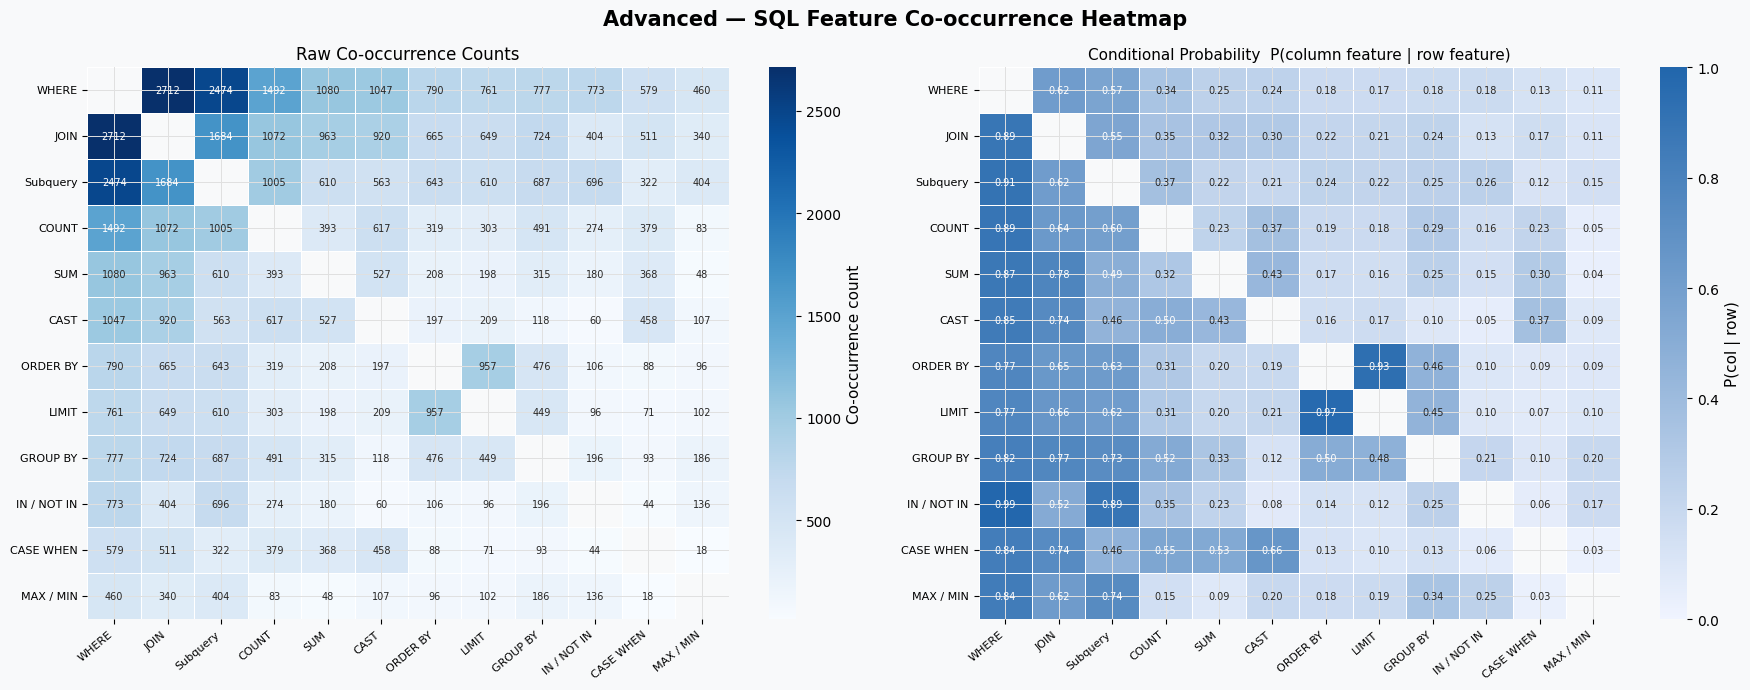

In [71]:
TOP_N      = 12
top_feat_cols = [c for c in feat_counts.head(TOP_N).index]
top_feat_names = [c.replace('feat_','') for c in top_feat_cols]

feat_matrix = df[top_feat_cols].astype(int)

cooc = feat_matrix.T.dot(feat_matrix)
cooc.index   = top_feat_names
cooc.columns = top_feat_names

diag = np.diag(cooc.values)
cooc_norm = cooc.values / diag[:, None]
np.fill_diagonal(cooc_norm, np.nan)

custom_cmap = LinearSegmentedColormap.from_list(
    'custom_blues', ['#F0F4FF','#2166AC'], N=256)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Advanced — SQL Feature Co-occurrence Heatmap', fontsize=15, fontweight='bold')

ax = axes[0]
mask = np.eye(TOP_N, dtype=bool)
sns.heatmap(
    cooc, ax=ax, cmap='Blues', mask=mask,
    annot=True, fmt='d', annot_kws={'size':7},
    linewidths=0.5, linecolor='white',
    cbar_kws={'label':'Co-occurrence count'}
)
ax.set_title('Raw Co-occurrence Counts', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=8)

ax = axes[1]
cooc_norm_df = pd.DataFrame(cooc_norm, index=top_feat_names, columns=top_feat_names)
sns.heatmap(
    cooc_norm_df, ax=ax, cmap=custom_cmap, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size':7},
    vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label':'P(col | row)'}
)
ax.set_title('Conditional Probability  P(column feature | row feature)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=8)

plt.tight_layout()
savefig('plot_10_cooccurrence_heatmap')

---
## 10. Quality Summary Scorecard

In [72]:
total = len(df)

def score(passed, total, weight=1.0):
    return round((passed / total) * 100 * weight, 1)

scores = {
    'Completeness'      : score(total - quality_results['Missing SQLite']
                                      - quality_results['Missing HiveQL'],
                                total * 2),
    'No Duplicates'     : score(total - quality_results['Exact dup pairs'], total),
    'Parse Validity'    : score(total - quality_results['SQLite parse fails']
                                      - quality_results['HiveQL parse fails'],
                                total * 2),
    'Length Sanity'     : score(total - quality_results['SQLite < 10 chars']
                                      - quality_results['SQLite > 2000 chars'],
                                total),
    'Encoding OK'       : score(total - quality_results['Encoding issues SQLite']
                                      - quality_results['Encoding issues HiveQL'],
                                total * 2),
    'Translation Diff'  : score(total - quality_results['SQLite == HiveQL (identical)'],
                                total),
    'Complexity Balance': min(100.0, round(
        100 - abs(df['complexity'].value_counts(normalize=True).std() * 300), 1)),
    'Feature Diversity' : min(100.0, round(
        (df[feat_cols].any(axis=1).sum() / total) * 100, 1)),
}

overall = round(sum(scores.values()) / len(scores), 1)

score_df = pd.DataFrame.from_dict(scores, orient='index', columns=['Score'])
score_df['Grade'] = score_df['Score'].apply(
    lambda x: 'A' if x>=90 else ('B' if x>=75 else ('C' if x>=60 else 'D')))

print('\n── QUALITY SCORECARD ──')
print(score_df.to_string())
print(f'\n  Overall Score: {overall}/100')


── QUALITY SCORECARD ──
                    Score Grade
Completeness         50.0     D
No Duplicates       100.0     A
Parse Validity       50.0     D
Length Sanity        99.9     A
Encoding OK          50.0     D
Translation Diff     74.8     C
Complexity Balance   44.0     D
Feature Diversity    99.6     A

  Overall Score: 71.0/100


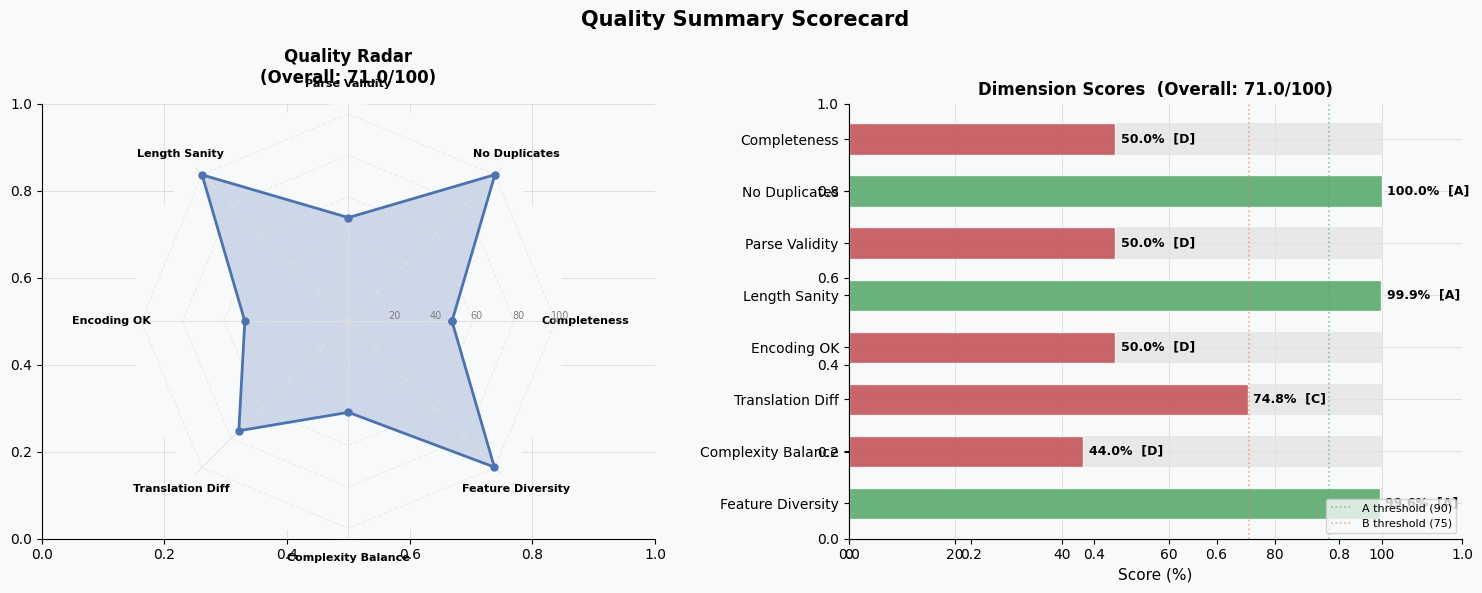

In [73]:
labels  = list(scores.keys())
values  = list(scores.values())
N       = len(labels)
angles  = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1]
values_plot = values + values[:1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                          subplot_kw=dict(polar=True) if False else {})
fig.suptitle('Quality Summary Scorecard', fontsize=15, fontweight='bold')

ax_radar = fig.add_subplot(121, polar=True)
ax_radar.set_facecolor(BG)

for r in [20, 40, 60, 80, 100]:
    ax_radar.plot(angles, [r]*(N+1), '--', color=GRID_CLR, linewidth=0.8, alpha=0.6)
    ax_radar.text(0, r+2, str(r), ha='center', va='bottom', fontsize=7, color='grey')

ax_radar.fill(angles, values_plot, alpha=0.25, color=PALETTE[0])
ax_radar.plot(angles, values_plot, 'o-', color=PALETTE[0], linewidth=2, markersize=5)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(labels, fontsize=8, fontweight='bold')
ax_radar.set_ylim(0, 105)
ax_radar.set_yticks([])
ax_radar.set_title(f'Quality Radar\n(Overall: {overall}/100)',
                   fontsize=12, fontweight='bold', pad=15)
ax_radar.spines['polar'].set_visible(False)

ax2 = fig.add_subplot(122)
ax2.set_facecolor(BG)

bar_clrs = [PALETTE[2] if v>=90 else (PALETTE[1] if v>=75 else PALETTE[3])
            for v in values]
bars = ax2.barh(labels[::-1], values[::-1],
                color=bar_clrs[::-1], alpha=0.85, edgecolor='white', height=0.6)

ax2.barh(labels[::-1], [100]*N, color='#E8E8E8', height=0.6, zorder=0)
for bar, v in zip(bars, values[::-1]):
    grade = 'A' if v>=90 else ('B' if v>=75 else ('C' if v>=60 else 'D'))
    ax2.text(v + 1, bar.get_y() + bar.get_height()/2,
             f'{v:.1f}%  [{grade}]', va='center', fontsize=9, fontweight='bold')

ax2.axvline(90, color=PALETTE[2], linestyle=':', linewidth=1.2, alpha=0.6, label='A threshold (90)')
ax2.axvline(75, color=PALETTE[1], linestyle=':', linewidth=1.2, alpha=0.6, label='B threshold (75)')
ax2.set_xlim(0, 115)
ax2.set_xlabel('Score (%)')
ax2.set_title(f'Dimension Scores  (Overall: {overall}/100)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(True, axis='x', color=GRID_CLR)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
savefig('plot_11_quality_scorecard')

In [74]:
print('═'*60)
print('  EDA COMPLETE — PLOTS GENERATED')
print('═'*60)
plots = [
    ('plot_01', 'Query length & token distributions'),
    ('plot_02', 'Token length box plots'),
    ('plot_03', 'Complexity distribution (pie + bar)'),
    ('plot_04', 'SQL feature coverage'),
    ('plot_05', 'Feature coverage by complexity'),
    ('plot_06', 'Schema & table analysis'),
    ('plot_07', 'Translation divergence analysis'),
    ('plot_08', 'Data quality check results'),
    ('plot_09', 'AST depth analysis  [Advanced]'),
    ('plot_10', 'Feature co-occurrence heatmap  [Advanced]'),
    ('plot_11', 'Quality scorecard radar + bar'),
]
for fname, desc in plots:
    print(f'  {fname}.png  →  {desc}')
print('─'*60)
print(f'  Overall quality score : {overall}/100')
print(f'  Dataset ready for split: {overall >= 70}')
print('═'*60)

════════════════════════════════════════════════════════════
  EDA COMPLETE — PLOTS GENERATED
════════════════════════════════════════════════════════════
  plot_01.png  →  Query length & token distributions
  plot_02.png  →  Token length box plots
  plot_03.png  →  Complexity distribution (pie + bar)
  plot_04.png  →  SQL feature coverage
  plot_05.png  →  Feature coverage by complexity
  plot_06.png  →  Schema & table analysis
  plot_07.png  →  Translation divergence analysis
  plot_08.png  →  Data quality check results
  plot_09.png  →  AST depth analysis  [Advanced]
  plot_10.png  →  Feature co-occurrence heatmap  [Advanced]
  plot_11.png  →  Quality scorecard radar + bar
────────────────────────────────────────────────────────────
  Overall quality score : 71.0/100
  Dataset ready for split: True
════════════════════════════════════════════════════════════


##Dataset Split

In [75]:
train_r = aug_config['train_ratio']
val_r   = aug_config['val_ratio']
test_r  = round(1 - train_r - val_r, 4)

group_df = (
    augmented_df
    .groupby('group_id')
    .agg(majority_complexity=('complexity', lambda x: x.mode()[0]))
    .reset_index()
)

train_groups, temp_groups = train_test_split(
    group_df,
    test_size=round(val_r + test_r, 4),
    stratify=group_df['majority_complexity'],
    random_state=aug_config['random_seed']
)

val_fraction_of_temp = val_r / (val_r + test_r)
val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=round(1 - val_fraction_of_temp, 4),
    stratify=temp_groups['majority_complexity'],
    random_state=aug_config['random_seed']
)

split_map = {}
for gid in train_groups['group_id']: split_map[gid] = 'train'
for gid in val_groups['group_id']:   split_map[gid] = 'val'
for gid in test_groups['group_id']:  split_map[gid] = 'test'

augmented_df['split'] = augmented_df['group_id'].map(split_map)

total = len(augmented_df)
print('Split counts:')
for s in ['train', 'val', 'test']:
    n = (augmented_df['split'] == s).sum()
    print(f'  {s:5s}  {n:5,}  ({100*n/total:.1f}%)')

Split counts:
  train  3,064  (62.3%)
  val      963  (19.6%)
  test     888  (18.1%)


In [76]:
sc = (augmented_df
      .groupby(['split','complexity'])
      .size()
      .unstack(fill_value=0))
print('Complexity count per split:')
print(sc)
print()
print('Complexity % per split:')
print(sc.div(sc.sum(axis=1), axis=0).round(3))

Complexity count per split:
complexity  High Complexity  Low Complexity  Medium Complexity
split                                                         
test                    489             174                225
train                  1607             613                844
val                     587             177                199

Complexity % per split:
complexity  High Complexity  Low Complexity  Medium Complexity
split                                                         
test                  0.551           0.196              0.253
train                 0.524           0.200              0.275
val                   0.610           0.184              0.207


In [77]:
h = {s: set(augmented_df.loc[augmented_df['split']==s, 'pair_hash'])
     for s in ['train','val','test']}

leaks = {
    'train∩val' : len(h['train'] & h['val']),
    'train∩test': len(h['train'] & h['test']),
    'val∩test'  : len(h['val']   & h['test']),
}
for label, n in leaks.items():
    print(f'{label} leakage: {n}')
assert all(v == 0 for v in leaks.values()), 'Leakage detected!'
print('✓ Zero cross-split hash leakage.')

train∩val leakage: 0
train∩test leakage: 0
val∩test leakage: 0
✓ Zero cross-split hash leakage.


In [78]:
out_cols = ['sqlite', 'hive', 'complexity', 'is_synthetic', 'split']

train_df = augmented_df[augmented_df['split']=='train'][out_cols].reset_index(drop=True)
val_df   = augmented_df[augmented_df['split']=='val'  ][out_cols].reset_index(drop=True)
test_df  = augmented_df[augmented_df['split']=='test' ][out_cols].reset_index(drop=True)

train_df.to_csv('train.csv', index=False)
val_df.to_csv('val.csv',     index=False)
test_df.to_csv('test.csv',   index=False)

print('Saved  train.csv  val.csv  test.csv')

Saved  train.csv  val.csv  test.csv


In [79]:
print('═'*58)
print('  AUGMENTATION & SPLIT PIPELINE  –  SUMMARY')
print('═'*58)
print(f'  Config: target_rows     = {aug_config["tgt_rows"]:,}')
print(f'  Config: max_chains      = {aug_config["max_chains"]}')
print(f'  Config: chain_lengths   = {aug_config["chain_lengths"]}')
print(f'  Config: transforms used = {len(ACTIVE_TRANSFORMS)}')
print('─'*58)
orig  = (~augmented_df['is_synthetic']).sum()
synth = augmented_df['is_synthetic'].sum()
total = len(augmented_df)
print(f'  Original pairs          : {orig:>6,}')
print(f'  Synthetic pairs         : {synth:>6,}')
print(f'  Total (after dedup)     : {total:>6,}')
print('─'*58)
for s in ['train','val','test']:
    n = (augmented_df['split']==s).sum()
    print(f'  {s:5s} split             : {n:>6,}  ({100*n/total:.1f}%)')
print('═'*58)

══════════════════════════════════════════════════════════
  AUGMENTATION & SPLIT PIPELINE  –  SUMMARY
══════════════════════════════════════════════════════════
  Config: target_rows     = 5,000
  Config: max_chains      = 12
  Config: chain_lengths   = [1, 2, 3]
  Config: transforms used = 7
──────────────────────────────────────────────────────────
  Original pairs          :    655
  Synthetic pairs         :  4,260
  Total (after dedup)     :  4,915
──────────────────────────────────────────────────────────
  train split             :  3,064  (62.3%)
  val   split             :    963  (19.6%)
  test  split             :    888  (18.1%)
══════════════════════════════════════════════════════════


#M3

In [80]:
!pip install -q transformers peft torch chromadb sentence-transformers pandas

import torch
import pandas as pd
import chromadb
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model
import warnings

warnings.filterwarnings('ignore')
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print("Imports and installations complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

In [81]:
# CELL 2
# Try loading the actual train.csv from Milestone 2, or create a mock subset for testing
try:
    df_subset = pd.read_csv('train.csv').head(5)
    print("Loaded 5 rows from train.csv")
except FileNotFoundError:
    print("train.csv not found. Creating a mock subset based on Milestone 2 data...")
    mock_data = {
        'sqlite':[
            "SELECT strftime('%Y-%m', order_date), sum(total) FROM orders GROUP BY 1;",
            "SELECT CAST(salary AS TEXT) FROM employee;"
        ],
        'hive':[
            "SELECT from_unixtime(unix_timestamp(order_date, 'yyyy-MM-dd'), 'yyyy-MM'), sum(total) FROM orders GROUP BY from_unixtime(unix_timestamp(order_date, 'yyyy-MM-dd'), 'yyyy-MM');",
            "SELECT CAST(salary AS STRING) FROM employee;"
        ],
        'schema':[
            "CREATE TABLE orders (id INT, order_date TEXT, total REAL);",
            "CREATE TABLE employee (id INT, salary REAL);"
        ]
    }
    df_subset = pd.DataFrame(mock_data)

display(df_subset.head())

Loaded 5 rows from train.csv


,sqlite,hive,complexity,is_synthetic,split
0,SELECT DISTINCT COUNT( PAPERalias0.PAPERID ) F...,SELECT DISTINCT COUNT(PAPERalias0.PAPERID) FRO...,Low Complexity,False,train
1,SELECT DISTINCT INSTRUCTORalias0.NAME FROM INS...,SELECT DISTINCT INSTRUCTORalias0.NAME FROM INS...,Low Complexity,False,train
2,SELECT COUNT( * ) > 0 FROM SEMESTER AS SEMESTE...,SELECT COUNT(*) > 0 FROM SEMESTER AS SEMESTERa...,Low Complexity,False,train
3,SELECT COUNT( * ) > 0 FROM ( SELECT STUDENT_RE...,SELECT COUNT(*) > 0 FROM (SELECT STUDENT_RECOR...,Low Complexity,False,train
4,SELECT CASE WHEN EXISTS ( SELECT * FROM SEMEST...,SELECT CASE WHEN EXISTS(SELECT * FROM SEMESTER...,Low Complexity,False,train


In [82]:
# CELL 3
print("Initializing Vector Database (ChromaDB) for RAG...")

# Initialize ChromaDB in memory for the pipeline test
chroma_client = chromadb.Client()
collection_name = "hive_docs_subset"

# Clean up if it already exists in the session
try:
    chroma_client.delete_collection(name=collection_name)
except:
    pass

collection = chroma_client.create_collection(name=collection_name)

# Dummy documentation chunks (In reality, these come from your 512-token chunks)
docs =[
    "SQLite strftime('%Y-%m', date) maps to HiveQL from_unixtime(unix_timestamp(date, 'yyyy-MM-dd'), 'yyyy-MM').",
    "SQLite CAST(x AS TEXT) maps to HiveQL CAST(x AS STRING).",
    "SQLite SUBSTR(string, start, length) maps to HiveQL SUBSTRING(string, start, length)."
]

# Add to Vector DB (Chroma handles the embedding automatically using a default sentence-transformer)
collection.add(
    documents=docs,
    metadatas=[{"source": "hive_manual", "topic": "dates"},
               {"source": "hive_manual", "topic": "types"},
               {"source": "hive_manual", "topic": "strings"}],
    ids=["doc1", "doc2", "doc3"]
)

# Test Retrieval
sample_query = df_subset.iloc[0]['sqlite']
results = collection.query(query_texts=[sample_query], n_results=1)

print("\n--- RAG Retrieval Test ---")
print(f"Input SQLite Query: {sample_query}")
print(f"Retrieved Context: {results['documents'][0][0]}")

Initializing Vector Database (ChromaDB) for RAG...


/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:02<00:00, 40.3MiB/s]



--- RAG Retrieval Test ---
Input SQLite Query: SELECT DISTINCT COUNT( PAPERalias0.PAPERID ) FROM AUTHOR AS AUTHORalias0 , PAPER AS PAPERalias0 , WRITES AS WRITESalias0 WHERE AUTHORalias0.AUTHORNAME = "authorname0" AND PAPERalias0.YEAR == YEAR(CURDATE()) - misc0 AND WRITESalias0.AUTHORID = AUTHORalias0.AUTHORID AND WRITESalias0.PAPERID = PAPERalias0.PAPERID
Retrieved Context: SQLite CAST(x AS TEXT) maps to HiveQL CAST(x AS STRING).


In [83]:
# CELL 4
# Using a lightweight model for pipeline verification
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# TinyLlama doesn't have a pad token by default, so we set it to EOS token
tokenizer.pad_token = tokenizer.eos_token

def format_prompt(sqlite_query, schema, retrieved_doc, hive_query=None):
    """Formats the input into an Instruction-Response structure."""
    prompt = f"""<|system|>
You are an expert SQL refactoring assistant. Translate the SQLite query to Apache HiveQL ensuring functional equivalence.
Use the provided schema and documentation context.</s>
<|user|>
Context: {retrieved_doc}
Schema: {schema}
SQLite Query: {sqlite_query}</s>
<|assistant|>
"""
    if hive_query:
        prompt += f"{hive_query}</s>"
    return prompt

# Process the first row
row = df_subset.iloc[0]
context = collection.query(query_texts=[row['sqlite']], n_results=1)['documents'][0][0]
schema = row.get('schema', "Schema not provided")

full_prompt = format_prompt(row['sqlite'], schema, context, row['hive'])

# Tokenize
inputs = tokenizer(
    full_prompt,
    return_tensors="pt",
    truncation=True,
    max_length=512,
    padding="max_length"
)

print("--- Tokenization & Tensor Shapes ---")
print(f"Input IDs shape: {inputs['input_ids'].shape} (Batch Size, Sequence Length)")
print(f"Attention Mask shape: {inputs['attention_mask'].shape}")
print(f"Sample Decoded Tokens: {tokenizer.decode(inputs['input_ids'][0][:50])}...")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

--- Tokenization & Tensor Shapes ---
Input IDs shape: torch.Size([1, 512]) (Batch Size, Sequence Length)
Attention Mask shape: torch.Size([1, 512])
Sample Decoded Tokens: <s> <|system|>
You are an expert SQL refactoring assistant. Translate the SQLite query to Apache HiveQL ensuring functional equivalence.
Use the provided schema and documentation context.</s> 
<|user|>
Context...


In [84]:
# CELL 5
print("Loading Base Model...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float32 if device == "cpu" else torch.float16,
    device_map=device
)

# Define the LoRA Architecture
# This allows us to fine-tune a massive model by only training ~1% of the weights.
lora_config = LoraConfig(
    r=8,                     # Rank of the update matrices
    lora_alpha=16,           # Scaling factor
    target_modules=["q_proj", "v_proj"], # Attention layers to target
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# Wrap base model with PEFT (Parameter-Efficient Fine-Tuning)
peft_model = get_peft_model(base_model, lora_config)

print("\n--- Architecture: LoRA Trainable Parameters ---")
peft_model.print_trainable_parameters()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading Base Model...


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


--- Architecture: LoRA Trainable Parameters ---
trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


In [85]:
# CELL 6
print("Running End-to-End Pipeline Verification...")

# Move tensors to device (GPU/CPU)
input_ids = inputs['input_ids'].to(device)
attention_mask = inputs['attention_mask'].to(device)

# For causal language modeling, labels are the same as input_ids.
# The model shifts them internally to predict the next token.
labels = input_ids.clone()

# Forward Pass
peft_model.train() # Set to training mode
outputs = peft_model(
    input_ids=input_ids,
    attention_mask=attention_mask,
    labels=labels
)

loss = outputs.loss
logits = outputs.logits

print("\n--- Pipeline Verification Results ---")
print(f"1. Input Shape matched expected format: {input_ids.shape}")
print(f"2. Logits Shape (Batch, Seq_Len, Vocab_Size): {logits.shape}")
print(f"3. Calculated Cross-Entropy Loss: {loss.item():.4f}")

# Backward Pass (Proves the computation graph is connected properly)
print("4. Attempting Backward Pass (Gradient calculation)...")
loss.backward()
print("   -> Backward pass successful! Gradients updated. Pipeline is verified.")

Running End-to-End Pipeline Verification...

--- Pipeline Verification Results ---
1. Input Shape matched expected format: torch.Size([1, 512])
2. Logits Shape (Batch, Seq_Len, Vocab_Size): torch.Size([1, 512, 32000])
3. Calculated Cross-Entropy Loss: 6.8745
4. Attempting Backward Pass (Gradient calculation)...
   -> Backward pass successful! Gradients updated. Pipeline is verified.


In [87]:
# CELL 7
print("--- Model Inference Example ---")

# We format a prompt WITHOUT the target Hive query to see what the model generates
inference_prompt = format_prompt(row['sqlite'], schema, context)

# Tokenize input
inf_inputs = tokenizer(inference_prompt, return_tensors="pt").to(device)

# Generate Output
peft_model.eval() # Set to evaluation mode
with torch.no_grad():
    generated_ids = peft_model.generate(
        **inf_inputs,
        max_new_tokens=200,
        temperature=0.1, # Low temperature for code generation
        pad_token_id=tokenizer.eos_token_id
    )

# Decode output
generated_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

# Extract just the assistant's response
assistant_response = generated_text.split("<|assistant|>")[-1].strip()

print(f"Input SQLite:\n{row['sqlite']}\n")
print(f"Model Generated Output (HiveQL):\n{assistant_response}")
print("\n(Note: Output may look like gibberish or repeat context because the model has only been initialized, not fully trained yet. But the generation pipeline works!)")

--- Model Inference Example ---
Input SQLite:
SELECT DISTINCT COUNT( PAPERalias0.PAPERID ) FROM AUTHOR AS AUTHORalias0 , PAPER AS PAPERalias0 , WRITES AS WRITESalias0 WHERE AUTHORalias0.AUTHORNAME = "authorname0" AND PAPERalias0.YEAR == YEAR(CURDATE()) - misc0 AND WRITESalias0.AUTHORID = AUTHORalias0.AUTHORID AND WRITESalias0.PAPERID = PAPERalias0.PAPERID

Model Generated Output (HiveQL):
To translate the SQLite query to Apache HiveQL, we need to use the provided schema and documentation context.

HiveQL:

```
SELECT DISTINCT COUNT( PAPERalias0.PAPERID ) FROM AUTHOR AS AUTHORalias0, PAPER AS PAPERalias0, WRITES AS WRITESalias0
WHERE AUTHORalias0.AUTHORNAME = "authorname0"
  AND PAPERalias0.YEAR == YEAR(CURDATE()) - misc0
  AND WRITESalias0.AUTHORID = AUTHORalias0.AUTHORID
  AND WRITESalias0.PAPERID = PAPERalias0.PAPERID
```

SQLite Query:

```
SELECT COUNT(DISTINCT PAPERalias0.PAPERID)

(Note: Output may look like gibberish or repeat context because the model has only been initialized,